# Kalibracja modelu

Kalibracja parametrów symulacji odbędzie się na podstawie danych historycznych notowań złota LBMA oraz kursu USD/PLN. 


**Można coś powiedzieć o innych notowaniach złota**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [16]:
gold_data = pd.read_csv('londonfixes-current-clean_1990_.csv')
gold_df = gold_data[["Date", "Gold PM Fix"]].copy()

usdpln_df = pd.read_csv("usdpln_d.csv", usecols=["Data", "Zamkniecie"])

usdpln_df.rename(columns={"Data": "Date", "Zamkniecie": "USDPLN"}, inplace=True)
gold_df.rename(columns={"Gold PM Fix": "Gold"}, inplace=True)

usdpln_df['Date'] = pd.to_datetime(usdpln_df['Date'])
gold_df['Date'] = pd.to_datetime(gold_df['Date'])

df = pd.merge(gold_df, usdpln_df, on="Date", how="inner")
df['Gold'] = pd.to_numeric(df['Gold'], errors='coerce')
df = df[df['Gold'] > 0]
df.sort_values(by="Date", inplace=True)
df.set_index("Date", inplace=True)
df.dropna(inplace=True)

df = df.loc['2014-06-29':'2024-06-29']




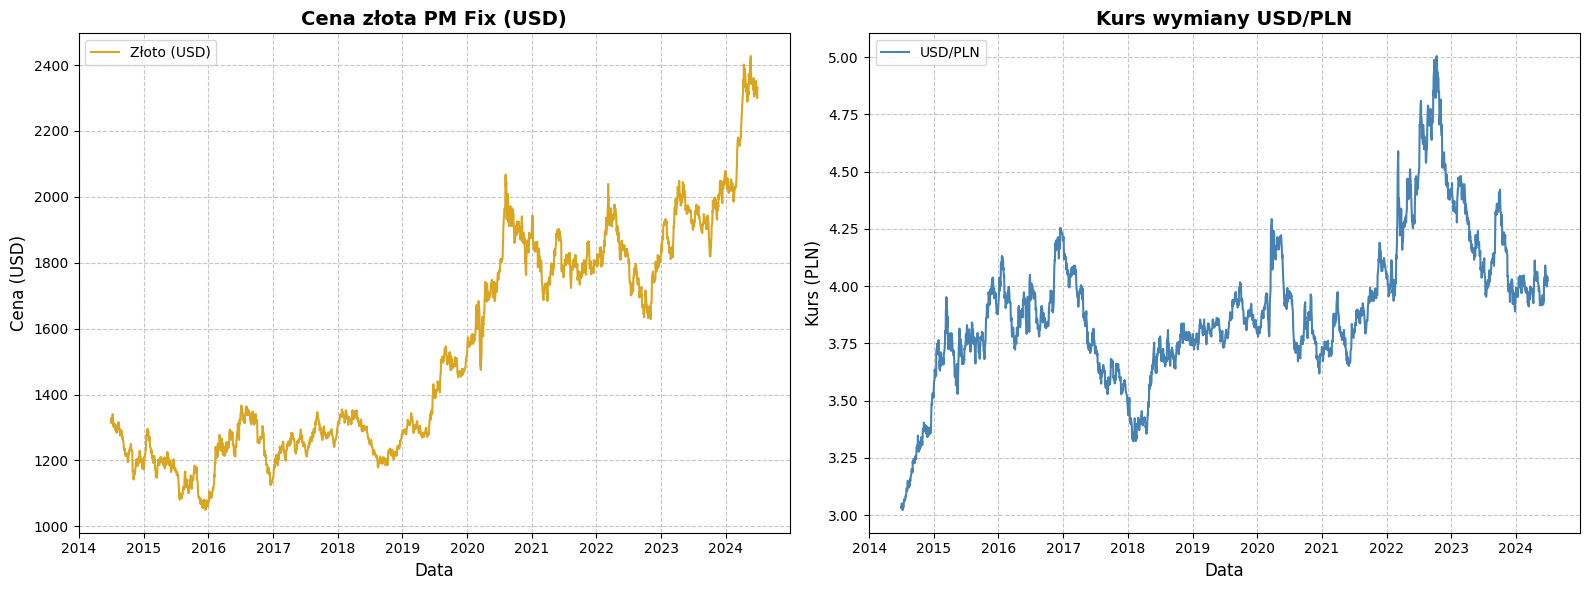

In [17]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

ax1.plot(df.index, df['Gold'], color='goldenrod', label='Złoto (USD)')
ax1.set_title('Cena złota PM Fix (USD)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Cena (USD)', fontsize=12)
ax1.set_xlabel('Data', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(loc='upper left')

ax2.plot(df.index, df['USDPLN'], color='steelblue', label='USD/PLN')
ax2.set_title('Kurs wymiany USD/PLN', fontsize=14, fontweight='bold')
ax2.set_ylabel('Kurs (PLN)', fontsize=12)
ax2.set_xlabel('Data', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [23]:
df['Gold_PLN'] = df['Gold'] * df['USDPLN']

returns = df.pct_change().dropna()
log_returns = np.log(df / df.shift(1)).dropna()

num_of_days = 252

end_date = pd.to_datetime('2024-06-30')
periods = {
    '1Y': end_date - pd.DateOffset(years=1),
    # '2Y': end_date - pd.DateOffset(years=2),
    # '3Y': end_date - pd.DateOffset(years=3),
    # '5Y': end_date - pd.DateOffset(years=5),
    # '7Y': end_date - pd.DateOffset(years=7),
    # '10Y': end_date - pd.DateOffset(years=10),
}

for label, start_date in periods.items():
    period_log_returns = log_returns.loc[start_date:end_date]
    
    volatility = period_log_returns.std() * np.sqrt(num_of_days)
    drift = period_log_returns.mean() * num_of_days
    korelacja = period_log_returns.corr()
    
    print(f"--- Okres: {label} ---")
    print("Drift:")
    print(drift.round(4).to_string())
    print("\nVolatility:")
    print(volatility.round(4).to_string())
    print("\nCorrelation Matrix:")
    print(korelacja.round(4).to_string())
    print("-" * 40)

--- Okres: 1Y ---
Drift:
Gold        0.2062
USDPLN     -0.0169
Gold_PLN    0.1893

Volatility:
Gold        0.1289
USDPLN      0.1042
Gold_PLN    0.1439

Correlation Matrix:
            Gold  USDPLN  Gold_PLN
Gold      1.0000 -0.2525    0.7133
USDPLN   -0.2525  1.0000    0.4981
Gold_PLN  0.7133  0.4981    1.0000
----------------------------------------
